# Seleção de Features para Análise de Sobrevivência



In [4]:
# !pip install lifelines scipy scikit-learn statsmodels matplotlib seaborn pandas numpy --quiet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2, spearmanr
from typing import Dict, List, Optional, Tuple, Any
from dataclasses import dataclass, field
import unittest
import io
import sys

from lifelines import KaplanMeierFitter, CoxPHFitter, NelsonAalenFitter
from lifelines.statistics import multivariate_logrank_test, logrank_test
from lifelines.utils import concordance_index
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']
sns.set_palette(PALETTE)
np.random.seed(42)

In [2]:
# teste

## Dados Falsos

In [3]:
def make_survival_dataset(
    n: int = 2000,
    n_events_target: int = 1,
    random_state: int = 42
) -> pd.DataFrame:
    """
    Gera dataset sintético de survival com features de diferentes tipos:
      - relevantes (linear, log-linear, não-linear)
      - irrelevantes (ruído)
      - correlacionadas entre si
      - com missing
      - categóricas com vários níveis

    Parameters
    ----------
    n               : número de observações
    n_events_target : 1 = default, 2 = prepagamento (competing risks)
    random_state    : semente aleatória

    Returns
    -------
    DataFrame com colunas:
      id, time, event (0=censura, 1=default, 2=prepag)
      + features diversas
    """
    rng = np.random.default_rng(random_state)

    # ── Features relevantes ───────────────────────────────────────────────────
    score        = rng.normal(600, 80, n).clip(300, 900)          # linear
    renda        = rng.lognormal(8.5, 0.6, n)                     # log-linear
    ltv          = rng.beta(2, 3, n) * 0.6 + 0.3                  # não-linear (U)
    prazo        = rng.choice([12, 24, 36, 48, 60], n)            # ordinal
    taxa         = rng.uniform(0.01, 0.06, n)                     # linear

    # ── Features correlacionadas com score ────────────────────────────────────
    score_alt    = score + rng.normal(0, 20, n)                   # ρ ≈ 0.97
    renda_alt    = np.log(renda) + rng.normal(0, 0.3, n)         # ρ ≈ 0.85

    # ── Features irrelevantes (ruído puro) ───────────────────────────────────
    ruido1       = rng.normal(0, 1, n)
    ruido2       = rng.uniform(0, 100, n)

    # ── Feature com alta taxa de missing ─────────────────────────────────────
    patrimonio   = rng.lognormal(10, 1, n)
    patrimonio[rng.random(n) < 0.65] = np.nan                     # 65% missing

    # ── Categórica com muitos níveis (alguns raros) ───────────────────────────
    segmento     = rng.choice(
        ['A', 'B', 'C', 'D', 'E', 'F'],
        n, p=[0.35, 0.30, 0.20, 0.08, 0.05, 0.02]
    )

    # ── Categórica binária relevante ─────────────────────────────────────────
    canal        = rng.choice(['digital', 'agencia'], n, p=[0.6, 0.4])

    # ── Predictor linear do hazard ────────────────────────────────────────────
    lp = (
        -3.0
        - 0.4 * (score / 600)
        + 1.5 * ltv
        + 2.0 * taxa * 12
        + 0.3 * (segmento == 'A').astype(float)
        - 0.2 * (canal == 'digital').astype(float)
        + rng.normal(0, 0.3, n)
    )

    # ── Tempos de evento ──────────────────────────────────────────────────────
    scale_def  = np.exp(-lp)
    scale_prep = np.exp(0.5 + 0.3 * np.log(renda / np.median(renda)))

    t_default = rng.weibull(1.5, n) * scale_def * 10
    t_prepag  = rng.weibull(0.8, n) * scale_prep * prazo
    t_cens    = rng.uniform(6, 48, n)

    t_obs = np.minimum(np.minimum(t_default, t_prepag), t_cens)
    t_obs = np.clip(np.round(t_obs).astype(int), 1, 60)

    evento = np.where(
        (t_default <= t_prepag) & (t_default <= t_cens), 1,
        np.where((t_prepag < t_default) & (t_prepag <= t_cens), 2, 0)
    )

    df = pd.DataFrame({
        'id'        : [f'ID{i:05d}' for i in range(n)],
        'time'      : t_obs,
        'event'     : evento,
        # Features relevantes
        'score'     : score.round(1),
        'renda'     : renda.round(2),
        'ltv'       : ltv.round(4),
        'prazo'     : prazo,
        'taxa'      : taxa.round(5),
        # Correlacionadas
        'score_alt' : score_alt.round(1),
        'renda_alt' : renda_alt.round(3),
        # Irrelevantes
        'ruido1'    : ruido1.round(3),
        'ruido2'    : ruido2.round(2),
        # Com missing
        'patrimonio': patrimonio.round(2),
        # Categóricas
        'segmento'  : segmento,
        'canal'     : canal,
    })
    return df


# ── Configuração global ───────────────────────────────────────────────────────
ID_COL    = 'id'
TIME_COL  = 'time'
EVENT_COL = 'event'

NUMERIC_FEATURES     = ['score', 'renda', 'ltv', 'prazo', 'taxa',
                         'score_alt', 'renda_alt', 'ruido1', 'ruido2', 'patrimonio']
CATEGORICAL_FEATURES = ['segmento', 'canal']
ALL_FEATURES         = NUMERIC_FEATURES + CATEGORICAL_FEATURES

df = make_survival_dataset(n=2000)

print(f'Shape: {df.shape}')
print(f'Evento 0 (censura)   : {(df.event==0).sum()} ({(df.event==0).mean():.1%})')
print(f'Evento 1 (default)   : {(df.event==1).sum()} ({(df.event==1).mean():.1%})')
print(f'Evento 2 (prepag)    : {(df.event==2).sum()} ({(df.event==2).mean():.1%})')
df.head(3)

Shape: (2000, 15)
Evento 0 (censura)   : 797 (39.9%)
Evento 1 (default)   : 439 (21.9%)
Evento 2 (prepag)    : 764 (38.2%)


,id,time,event,score,renda,ltv,prazo,taxa,score_alt,renda_alt,ruido1,ruido2,patrimonio,segmento,canal
0,ID00000,11,0,624.4,3747.44,0.5346,36,0.02284,648.1,8.647,0.635,39.19,17157.45,B,digital
1,ID00001,15,0,516.8,3296.03,0.6974,48,0.03175,555.9,8.101,0.517,83.68,NaN,B,agencia
2,ID00002,11,0,660.0,6376.70,0.4173,36,0.02140,691.2,9.351,0.339,49.34,7055.10,A,agencia


## Fase 1: Triagem
Quais features não devo considerar? 

Objetivo: reduzir o universo sem perder sinal, de forma objetiva e documentável.


In [ ]:
# Critérios de exclusão automática
MISSING_RATE_THRESHOLD = 0.6
NO_ZERO_VARIANCE = True
VARIANCE_THRESHOLD = 0.95


── Fase 1: Triagem Automática ───────────────────────
  Candidatas iniciais : 12
  Excluídas           : 1
  Mantidas            : 11

  Motivos de exclusão:
    ✗ patrimonio          : missing rate = 62.5%
────────────────────────────────────────────────────


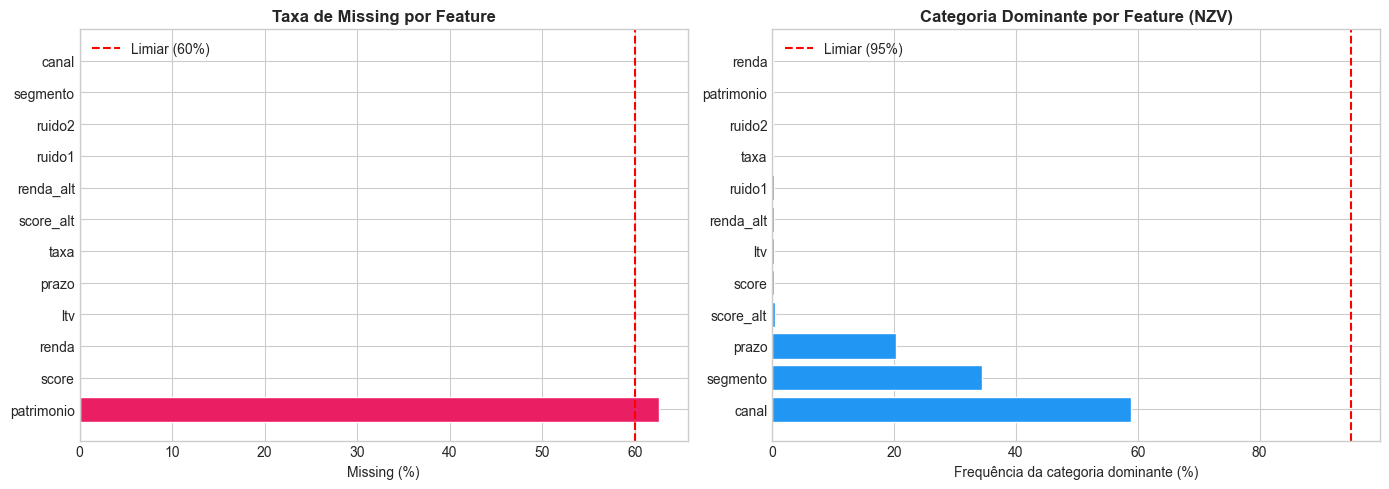

In [5]:

# ─────────────────────────────────────────────────────────────────────────────
# FASE 1 — TRIAGEM
# ─────────────────────────────────────────────────────────────────────────────

def compute_missing_rate(
    df: pd.DataFrame,
    features: List[str]
) -> pd.Series:
    """
    Calcula a taxa de missing de cada feature.

    Parameters
    ----------
    df       : DataFrame com as features
    features : lista de colunas a avaliar

    Returns
    -------
    Series com índice = feature e valor = taxa de missing [0, 1]
    """
    return df[features].isnull().mean().sort_values(ascending=False)


def compute_near_zero_variance(
    df: pd.DataFrame,
    features: List[str],
    max_dominant_pct: float = 0.95
) -> pd.DataFrame:
    """
    Identifica features com variância zero ou quase zero.

    Uma feature é near-zero variance se sua categoria/valor mais frequente
    representa mais de `max_dominant_pct` das observações não-nulas.

    Parameters
    ----------
    df               : DataFrame
    features         : lista de features a avaliar
    max_dominant_pct : limiar para considerar near-zero variance

    Returns
    -------
    DataFrame com colunas: feature, dominant_pct, n_unique, flag_nzv
    """
    rows = []
    for feat in features:
        if feat not in df.columns:
            continue
        s = df[feat].dropna()
        if len(s) == 0:
            rows.append({'feature': feat, 'dominant_pct': 1.0,
                         'n_unique': 0, 'flag_nzv': True})
            continue
        dominant_pct = s.value_counts(normalize=True).iloc[0]
        n_unique     = s.nunique()
        rows.append({
            'feature'      : feat,
            'dominant_pct' : round(dominant_pct, 4),
            'n_unique'     : n_unique,
            'flag_nzv'     : dominant_pct >= max_dominant_pct or n_unique <= 1,
        })
    return pd.DataFrame(rows)


def screen_features(
    df: pd.DataFrame,
    features: List[str],
    max_missing_rate: float = 0.60,
    max_dominant_pct: float = 0.95,
    verbose: bool = True
) -> Dict[str, Any]:
    """
    Fase 1 completa: aplica todos os critérios de triagem automática.

    Critérios:
      - Missing rate > max_missing_rate  → excluída
      - Near-zero variance               → excluída

    Parameters
    ----------
    df               : DataFrame
    features         : lista de features candidatas
    max_missing_rate : limiar de missing para exclusão
    max_dominant_pct : limiar NZV
    verbose          : imprime relatório

    Returns
    -------
    dict com:
      'kept'            : features que passaram na triagem
      'excluded'        : features excluídas
      'exclusion_reason': dict feature → motivo
      'missing_rates'   : Series com taxa de missing de todas
      'nzv_report'      : DataFrame do diagnóstico NZV
    """
    missing_rates = compute_missing_rate(df, features)
    nzv_report    = compute_near_zero_variance(df, features, max_dominant_pct)

    excluded        = {}
    excluded_reason = {}

    for feat in features:
        mr = missing_rates.get(feat, 0.0)
        if mr > max_missing_rate:
            excluded[feat]        = mr
            excluded_reason[feat] = f'missing rate = {mr:.1%}'
            continue
        nzv_row = nzv_report[nzv_report['feature'] == feat]
        if not nzv_row.empty and nzv_row['flag_nzv'].values[0]:
            excluded[feat]        = nzv_row['dominant_pct'].values[0]
            excluded_reason[feat] = (
                f'near-zero variance: dominant={nzv_row["dominant_pct"].values[0]:.1%}, '
                f'n_unique={nzv_row["n_unique"].values[0]}'
            )

    kept = [f for f in features if f not in excluded]

    if verbose:
        print('── Fase 1: Triagem Automática ───────────────────────')
        print(f'  Candidatas iniciais : {len(features)}')
        print(f'  Excluídas           : {len(excluded)}')
        print(f'  Mantidas            : {len(kept)}')
        if excluded_reason:
            print('\n  Motivos de exclusão:')
            for feat, reason in excluded_reason.items():
                print(f'    ✗ {feat:<20}: {reason}')
        print('────────────────────────────────────────────────────')

    return {
        'kept'            : kept,
        'excluded'        : list(excluded.keys()),
        'exclusion_reason': excluded_reason,
        'missing_rates'   : missing_rates,
        'nzv_report'      : nzv_report,
    }


def plot_screening_report(
    screening_result: Dict[str, Any],
    max_missing_rate: float = 0.60
):
    """
    Visualiza os resultados da triagem automática.

    Parameters
    ----------
    screening_result : saída de screen_features()
    max_missing_rate : limiar de corte (linha vermelha no gráfico)
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Missing rates
    mr = screening_result['missing_rates']
    colors = [PALETTE[1] if v > max_missing_rate else PALETTE[0] for v in mr.values]
    axes[0].barh(mr.index, mr.values * 100, color=colors, edgecolor='white')
    axes[0].axvline(max_missing_rate * 100, color='red', linestyle='--',
                    linewidth=1.5, label=f'Limiar ({max_missing_rate:.0%})')
    axes[0].set_title('Taxa de Missing por Feature', fontweight='bold')
    axes[0].set_xlabel('Missing (%)')
    axes[0].legend()

    # NZV
    nzv = screening_result['nzv_report'].sort_values('dominant_pct', ascending=False)
    colors2 = [PALETTE[1] if v else PALETTE[0] for v in nzv['flag_nzv']]
    axes[1].barh(nzv['feature'], nzv['dominant_pct'] * 100, color=colors2, edgecolor='white')
    axes[1].axvline(95, color='red', linestyle='--', linewidth=1.5, label='Limiar (95%)')
    axes[1].set_title('Categoria Dominante por Feature (NZV)', fontweight='bold')
    axes[1].set_xlabel('Frequência da categoria dominante (%)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# ── Uso ──────────────────────────────────────────────────────────────────────
screening = screen_features(df, ALL_FEATURES)
plot_screening_report(screening)
FEATURES_AFTER_SCREENING = screening['kept']

## Fase 2: Forma Funcional
Como devo entrar cada feature? 

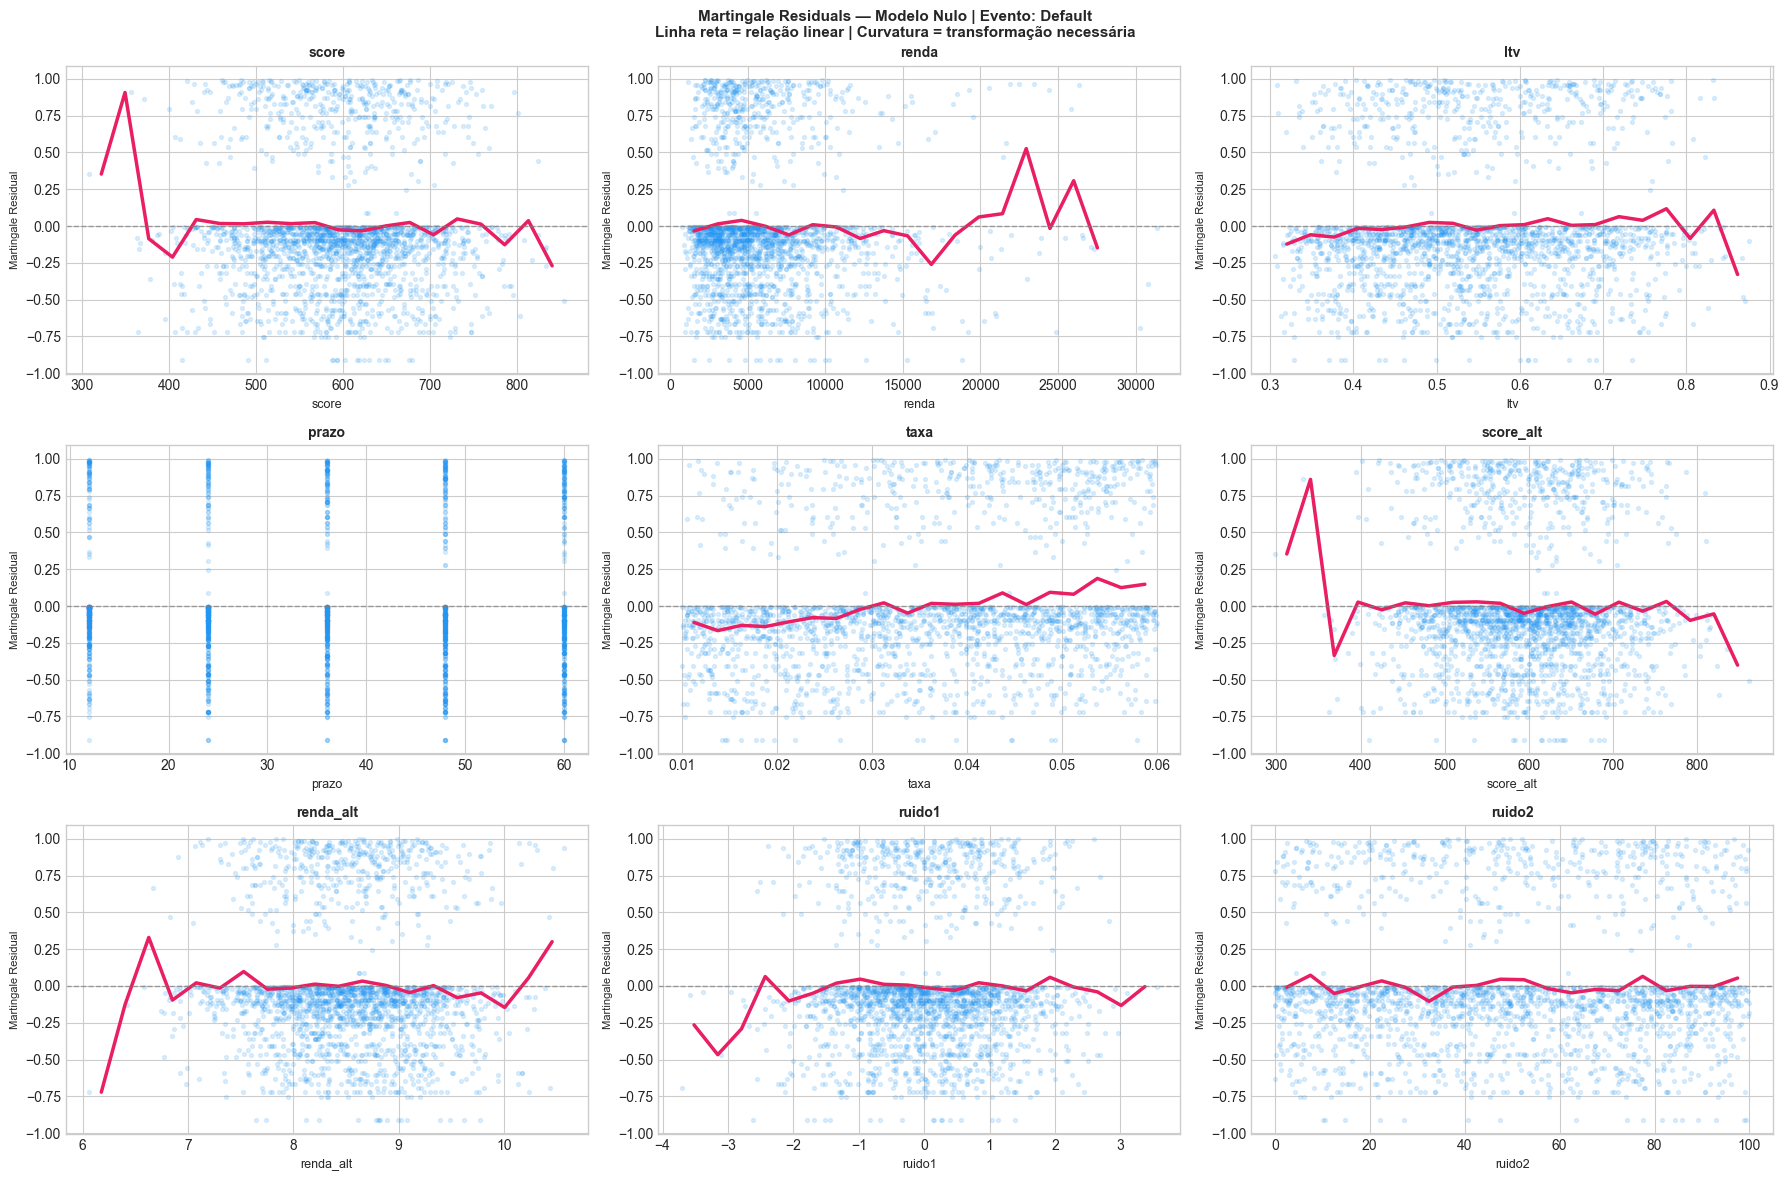

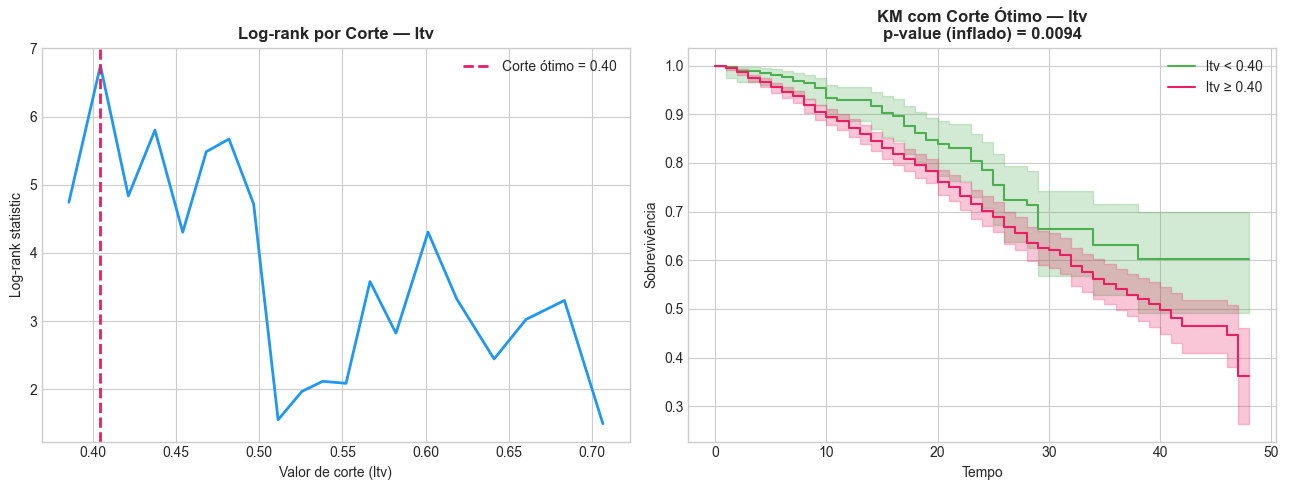


Avaliação de níveis — segmento:
level  n_obs  n_events  event_rate  median_survival  flag_few_events  collapse_candidate
    A    690       165      0.2391             35.0            False               False
    B    616       126      0.2045             47.0            False               False
    C    388        77      0.1985             46.0            False               False
    D    173        42      0.2428             40.0            False               False
    E    101        22      0.2178              inf             True                True
    F     32         7      0.2188             39.0             True                True


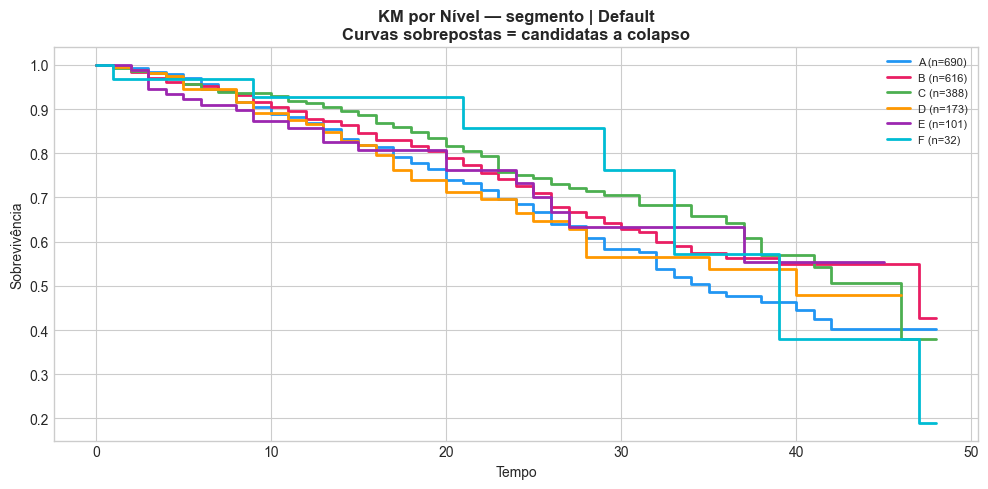

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# FASE 2 — FORMA FUNCIONAL
# ─────────────────────────────────────────────────────────────────────────────

def compute_martingale_residuals(
    df: pd.DataFrame,
    time_col: str,
    event_col: str,
    target_event: int = 1
) -> np.ndarray:
    """
    Calcula resíduos de martingale do modelo nulo (sem covariáveis).

    Resíduo de martingale = evento_observado - hazard_acumulado_esperado
    Usado para diagnosticar a forma funcional de cada feature contínua.

    Curvatura no plot resíduo vs feature indica relação não-linear
    com o log-hazard → feature precisa de transformação.

    Parameters
    ----------
    df           : DataFrame
    time_col     : coluna de tempo
    event_col    : coluna de evento (pode ser competing risks 0/1/2)
    target_event : código do evento de interesse

    Returns
    -------
    Array de resíduos de martingale (mesmo índice que df)
    """
    event_binary = (df[event_col] == target_event).astype(int)

    naf = NelsonAalenFitter()
    naf.fit(df[time_col], event_observed=event_binary)

    H0 = naf.cumulative_hazard_at_times(df[time_col]).values
    return event_binary.values - H0


def plot_martingale_residuals(
    df: pd.DataFrame,
    features: List[str],
    time_col: str,
    event_col: str,
    target_event: int = 1,
    n_bins_smooth: int = 20,
    ncols: int = 3
):
    """
    Plota resíduos de martingale vs cada feature contínua.

    Interpretação:
      - Linha de tendência reta inclinada → relação linear → entra como está
      - Linha plana                       → feature irrelevante
      - Curvatura                         → relação não-linear → transformar
      - Forma em U ou S                   → considerar binning

    Parameters
    ----------
    df             : DataFrame
    features       : features contínuas a avaliar
    time_col       : coluna de tempo
    event_col      : coluna de evento
    target_event   : evento de interesse
    n_bins_smooth  : número de bins para a linha de tendência suavizada
    ncols          : colunas no grid de plots
    """
    resid = compute_martingale_residuals(df, time_col, event_col, target_event)
    nrows = int(np.ceil(len(features) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for i, feat in enumerate(features):
        ax = axes[i]
        if feat not in df.columns:
            ax.set_visible(False)
            continue

        x = df[feat].values
        valid = ~np.isnan(x)

        ax.scatter(x[valid], resid[valid], alpha=0.15, s=8, color=PALETTE[0])

        # Linha de tendência via médias por bin
        try:
            means, edges, _ = stats.binned_statistic(
                x[valid], resid[valid], statistic='mean', bins=n_bins_smooth
            )
            centers = (edges[:-1] + edges[1:]) / 2
            ax.plot(centers, means, color=PALETTE[1], linewidth=2.5)
        except Exception:
            pass

        ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        ax.set_xlabel(feat, fontsize=9)
        ax.set_ylabel('Martingale Residual', fontsize=8)
        ax.set_title(feat, fontweight='bold', fontsize=10)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    event_label = {1: 'Default', 2: 'Prepagamento'}.get(target_event, str(target_event))
    plt.suptitle(
        f'Martingale Residuals — Modelo Nulo | Evento: {event_label}\n'
        'Linha reta = relação linear | Curvatura = transformação necessária',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


def find_optimal_cutpoint(
    df: pd.DataFrame,
    feature: str,
    time_col: str,
    event_col: str,
    target_event: int = 1,
    n_quantiles: int = 20
) -> Dict[str, Any]:
    """
    Encontra o ponto de corte ótimo de uma variável contínua via
    maximização do log-rank test.

    ATENÇÃO: o p-value no corte ótimo é inflado (multiple testing).
    Use apenas para orientar onde cortar; valide em conjunto separado.

    Parameters
    ----------
    df           : DataFrame
    feature      : nome da feature contínua
    time_col     : coluna de tempo
    event_col    : coluna de evento
    target_event : evento de interesse
    n_quantiles  : número de cortes a testar

    Returns
    -------
    dict com:
      'optimal_cutpoint' : valor do corte ótimo
      'logrank_stat'     : estatística no corte ótimo
      'logrank_pvalue'   : p-value (inflado — usar com cautela)
      'all_results'      : DataFrame com todos os cortes testados
    """
    sub = df[[feature, time_col, event_col]].dropna()
    event_binary = (sub[event_col] == target_event).astype(int)

    quantiles  = np.linspace(0.10, 0.90, n_quantiles)
    cutpoints  = sub[feature].quantile(quantiles).unique()

    rows = []
    for cut in cutpoints:
        grp = (sub[feature] >= cut).astype(int)
        if grp.nunique() < 2:
            continue
        try:
            result = logrank_test(
                sub.loc[grp == 0, time_col],
                sub.loc[grp == 1, time_col],
                event_observed_A=event_binary[grp == 0],
                event_observed_B=event_binary[grp == 1]
            )
            rows.append({
                'cutpoint'    : cut,
                'logrank_stat': result.test_statistic,
                'pvalue'      : result.p_value,
                'n_below'     : (grp == 0).sum(),
                'n_above'     : (grp == 1).sum(),
            })
        except Exception:
            continue

    all_df  = pd.DataFrame(rows)
    if all_df.empty:
        return {'optimal_cutpoint': None, 'logrank_stat': None,
                'logrank_pvalue': None, 'all_results': all_df}

    best    = all_df.loc[all_df['logrank_stat'].idxmax()]
    return {
        'optimal_cutpoint': best['cutpoint'],
        'logrank_stat'    : best['logrank_stat'],
        'logrank_pvalue'  : best['pvalue'],
        'all_results'     : all_df,
    }


def plot_cutpoint_search(
    cutpoint_result: Dict[str, Any],
    df: pd.DataFrame,
    feature: str,
    time_col: str,
    event_col: str,
    target_event: int = 1
):
    """
    Plota a busca pelo corte ótimo e as curvas KM resultantes.

    Parameters
    ----------
    cutpoint_result : saída de find_optimal_cutpoint()
    df              : DataFrame
    feature         : nome da feature
    time_col        : coluna de tempo
    event_col       : coluna de evento
    target_event    : evento de interesse
    """
    opt_cut = cutpoint_result['optimal_cutpoint']
    all_res = cutpoint_result['all_results']

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Log-rank stat por corte
    axes[0].plot(all_res['cutpoint'], all_res['logrank_stat'],
                 color=PALETTE[0], linewidth=2)
    if opt_cut is not None:
        axes[0].axvline(opt_cut, color=PALETTE[1], linestyle='--',
                        linewidth=2, label=f'Corte ótimo = {opt_cut:.2f}')
    axes[0].set_title(f'Log-rank por Corte — {feature}', fontweight='bold')
    axes[0].set_xlabel(f'Valor de corte ({feature})')
    axes[0].set_ylabel('Log-rank statistic')
    axes[0].legend()

    # KM com o corte ótimo
    if opt_cut is not None:
        sub = df[[feature, time_col, event_col]].dropna()
        grp = sub[feature] >= opt_cut
        event_binary = (sub[event_col] == target_event).astype(int)

        for mask, label, color in [
            (~grp, f'{feature} < {opt_cut:.2f}', PALETTE[2]),
            ( grp, f'{feature} ≥ {opt_cut:.2f}', PALETTE[1]),
        ]:
            kmf = KaplanMeierFitter(label=label)
            kmf.fit(sub.loc[mask, time_col], event_binary[mask])
            kmf.plot_survival_function(ax=axes[1], color=color, ci_show=True)

        axes[1].set_title(f'KM com Corte Ótimo — {feature}\n'
                          f'p-value (inflado) = {cutpoint_result["logrank_pvalue"]:.4f}',
                          fontweight='bold')
        axes[1].set_xlabel('Tempo')
        axes[1].set_ylabel('Sobrevivência')

    plt.tight_layout()
    plt.show()


def evaluate_categorical_levels(
    df: pd.DataFrame,
    feature: str,
    time_col: str,
    event_col: str,
    target_event: int = 1,
    min_events_per_level: int = 30
) -> pd.DataFrame:
    """
    Avalia quantos e quais níveis de uma variável categórica colapsar.

    Para cada par de níveis, testa se as curvas KM são diferentes.
    Níveis sem diferença significativa (p > 0.05) ou com poucos eventos
    são candidatos a colapso.

    Parameters
    ----------
    df                   : DataFrame
    feature              : coluna categórica
    time_col             : coluna de tempo
    event_col            : coluna de evento
    target_event         : evento de interesse
    min_events_per_level : mínimo de eventos para um nível ser mantido

    Returns
    -------
    DataFrame com nível, n_obs, n_events, median_survival,
    flag_few_events, sugestão de colapso
    """
    sub = df[[feature, time_col, event_col]].dropna()
    event_binary = (sub[event_col] == target_event).astype(int)

    rows = []
    for level in sorted(sub[feature].unique()):
        mask = sub[feature] == level
        t    = sub.loc[mask, time_col]
        e    = event_binary[mask]

        kmf = KaplanMeierFitter()
        kmf.fit(t, event_observed=e)

        rows.append({
            'level'            : level,
            'n_obs'            : mask.sum(),
            'n_events'         : e.sum(),
            'event_rate'       : round(e.mean(), 4),
            'median_survival'  : kmf.median_survival_time_,
            'flag_few_events'  : e.sum() < min_events_per_level,
        })

    result = pd.DataFrame(rows)
    result['collapse_candidate'] = result['flag_few_events']
    return result


def plot_categorical_km(
    df: pd.DataFrame,
    feature: str,
    time_col: str,
    event_col: str,
    target_event: int = 1,
    max_levels: int = 8
):
    """
    Plota curvas KM por nível da variável categórica.
    Níveis com curvas sobrepostas são candidatos a colapso.

    Parameters
    ----------
    df           : DataFrame
    feature      : coluna categórica
    time_col     : coluna de tempo
    event_col    : coluna de evento
    target_event : evento de interesse
    max_levels   : máximo de níveis a plotar
    """
    sub = df[[feature, time_col, event_col]].dropna()
    event_binary = (sub[event_col] == target_event).astype(int)
    levels = sorted(sub[feature].unique())[:max_levels]

    fig, ax = plt.subplots(figsize=(10, 5))
    for level, color in zip(levels, PALETTE * 3):
        mask = sub[feature] == level
        kmf  = KaplanMeierFitter(label=f'{level} (n={mask.sum()})')
        kmf.fit(sub.loc[mask, time_col], event_observed=event_binary[mask])
        kmf.plot_survival_function(ax=ax, color=color, ci_show=False, linewidth=2)

    event_label = {1: 'Default', 2: 'Prepagamento'}.get(target_event, str(target_event))
    ax.set_title(f'KM por Nível — {feature} | {event_label}\n'
                 'Curvas sobrepostas = candidatas a colapso', fontweight='bold')
    ax.set_xlabel('Tempo')
    ax.set_ylabel('Sobrevivência')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


# ── Uso ──────────────────────────────────────────────────────────────────────
numeric_for_martingale = [f for f in FEATURES_AFTER_SCREENING
                          if f in NUMERIC_FEATURES]

plot_martingale_residuals(df, numeric_for_martingale, TIME_COL, EVENT_COL, target_event=1)

# Busca corte ótimo para LTV (relação não-linear)
cut_result = find_optimal_cutpoint(df, 'ltv', TIME_COL, EVENT_COL)
plot_cutpoint_search(cut_result, df, 'ltv', TIME_COL, EVENT_COL)

# Avalia níveis da categórica
cat_levels = evaluate_categorical_levels(df, 'segmento', TIME_COL, EVENT_COL)
print('\nAvaliação de níveis — segmento:')
print(cat_levels.to_string(index=False))
plot_categorical_km(df, 'segmento', TIME_COL, EVENT_COL)

Linha reta inclinada  → relação linear com o log-hazard → entra como está  
Linha plana em zero   → feature não tem relação com o hazard → candidata à exclusão  
Curvatura             → relação não-linear → precisa transformar  

## Log-Rank Test

As curvas de sobrevivência de dois ou mais grupos são estatisticamente iguais, ou há evidência de que o tempo até o evento é diferente entre eles? (É o equivalente ao teste t para survival, respeitando a censura). Em cada MOB t onde ocorre pelo menos um evento, você tem:
- Quantos eventos REALMENTE ocorreram em cada grupo
- Quantos eventos SERIAM ESPERADOS em cada grupo se os grupos tivessem o mesmo risco

O log-rank soma essas diferenças (observado − esperado) ao longo de todos os tempos de evento. Se a soma for grande, os grupos têm risco diferente. Se for próxima de zero, os grupos se comportam igual.

O cálculo passo a passo
Em cada tempo tₖ onde ocorre pelo menos um evento:
nₖ  = total de contratos em risco em tₖ  (todos os grupos)
n₁ₖ = contratos em risco no grupo 1
n₂ₖ = contratos em risco no grupo 2
dₖ  = total de eventos em tₖ
d₁ₖ = eventos observados no grupo 1
d₂ₖ = eventos observados no grupo 2
O número de eventos esperado no grupo 1, assumindo que os grupos têm o mesmo risco:
E₁ₖ = n₁ₖ × (dₖ / nₖ)

"Se o risco fosse igual, o grupo 1 deveria ter uma fração
 proporcional ao seu tamanho no risk set"
A diferença observado − esperado em cada tempo:
O₁ₖ - E₁ₖ  =  d₁ₖ - n₁ₖ × (dₖ / nₖ)

A estatística final soma essas diferenças ao longo de todos os tempos de evento e padroniza pela variância:
         [ Σₖ (O₁ₖ - E₁ₖ) ]²
Z  =   ─────────────────────────
              Σₖ Vₖ

onde Vₖ é a variância hipergeométrica em cada tempo tₖ
Sob a hipótese nula (curvas iguais), Z segue uma distribuição qui-quadrado com 1 grau de liberdade (ou k-1 para k grupos).

Exemplo numérico mínimo
Dois grupos, três tempos de evento:
Tempo  n₁  n₂  d₁  d₂  E₁ = n₁×d/n   O₁-E₁
  5    50  50   3   1   50×4/100=2.0   3-2.0 = +1.0
 10    45  48   2   4   45×6/93 =2.9   2-2.9 = -0.9
 15    40  42   5   2   40×7/82 =3.4   5-3.4 = +1.6

Σ(O₁-E₁) = 1.0 - 0.9 + 1.6 = +1.7
Se essa soma for grande relativa à variância acumulada, o p-value é pequeno e você rejeita a hipótese de curvas iguais.

O que o log-rank detecta bem e o que não detecta
Detecta bem:
Diferenças que são consistentes ao longo do tempo — um grupo tem hazard sistematicamente maior que o outro em todos os MOBs. É exatamente a situação onde a suposição de hazards proporcionais vale.
Detecta mal:
Diferenças que aparecem só no início ou só no final do follow-up, ou quando as curvas se cruzam. Nesses casos, os termos positivos e negativos da soma se cancelam e a estatística fica pequena mesmo havendo diferença real.
No gráfico que você mostrou do LTV, esse é exatamente o problema — a separação aparece principalmente nos MOBs mais longos. O log-rank deu p = 0.0094, mas parte disso pode estar sendo diluído pela sobreposição nos MOBs iniciais.

A ligação com o que você está fazendo
No pipeline de feature selection, você usa o log-rank de duas formas:
Triagem inicial — discretiza a feature em quartis e testa se as curvas dos quartis são iguais. Feature com p > 0.20 provavelmente não tem relação com o hazard e pode ser descartada antes de rodar o Cox.
Busca do corte ótimo — testa todos os cortes possíveis e escolhe o que maximiza a estatística log-rank. O gráfico da esquerda que você viu é literalmente o plot dessa estatística em função do corte testado — o pico é onde a separação entre os dois grupos é máxima.
A distinção importante: o log-rank é um teste de igualdade de curvas, não uma medida de efeito. Ele te diz se existe diferença, mas não quão grande ela é. Para medir magnitude você precisa do hazard ratio (Cox) ou da diferença entre as CIFs (Aalen-Johansen).

A distinção importante: o log-rank é um teste de igualdade de curvas, não uma medida de efeito. Ele te diz se existe diferença, mas não quão grande ela é. . Para medir magnitude você precisa do hazard ratio (Cox) ou da diferença entre as CIFs (Aalen-Johansen).

## Função Log-Rank para Encontrar Candidatos a Colapso

In [1]:
#feat